Matched cases: 15
 Flow_Rate  Phi
      1400 0.85
      1400 0.90
      1400 1.00
      1400 1.18
      1400 1.37
      2300 0.85
      2300 0.90
      2300 1.00
      2300 1.18
      2300 1.37
       500 0.85
       500 0.90
       500 1.00
       500 1.18
       500 1.37

Total (intensity, temperature) pairs: 120
 Flow_Rate  Phi   TC   Point  Intensity  Temperature
      1400 0.85 TC17 Win1 P1   23039.83     416.7279
      1400 0.85 TC18 Win1 P2   22780.46     417.8053
      1400 0.85 TC19 Win1 P3   22065.26     420.3699
      1400 0.85 TC20 Win1 P4   23522.38     423.5984
      1400 0.85 TC22 Win2 P1   22871.46     420.0922
      1400 0.85 TC23 Win2 P2   21412.99     409.2126
      1400 0.85 TC24 Win2 P3   21132.38     396.5247
      1400 0.85 TC25 Win2 P4   22992.28     416.2836
      1400 0.90 TC17 Win1 P1   25658.96     460.1830
      1400 0.90 TC18 Win1 P2   25623.11     463.0706

── Linear Regression Results ──────────────────────────────
  Slope     (a): 0.015356  °C / count
 

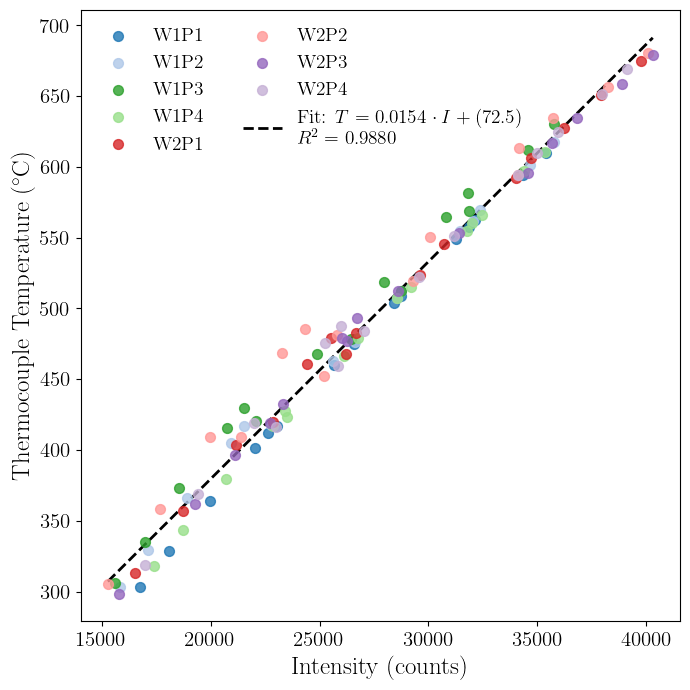


Plot saved to intensity_temperature_regression.png
Paired data saved to intensity_temperature_pairs.csv


In [1]:
"""
Intensity–Temperature Linear Regression
----------------------------------------
Matches cases by cooling flow rate (CR/Flow Rate) and equivalence ratio (Phi),
pairs each optical intensity measurement with its corresponding thermocouple
temperature, then fits a global linear regression across all data points.

TC–to–Window/Point mapping:
  TC17 → Win1 P1 | TC18 → Win1 P2 | TC19 → Win1 P3 | TC20 → Win1 P4
  TC22 → Win2 P1 | TC23 → Win2 P2 | TC24 → Win2 P3 | TC25 → Win2 P4
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ── File paths ──────────────────────────────────────────────────────────────
INTENSITY_FILE = r"D:\FCAI\plain_coupon\summary_calibration\intensity_summary_use.xlsx"
TC_FILE        = r"D:\FCAI\plain_coupon\summary_calibration\time_average_summary_use.xlsx"

# ── TC → intensity-column mapping ───────────────────────────────────────────
TC_MAP = {
    "TC17": "Win1 P1",
    "TC18": "Win1 P2",
    "TC19": "Win1 P3",
    "TC20": "Win1 P4",
    "TC22": "Win2 P1",
    "TC23": "Win2 P2",
    "TC24": "Win2 P3",
    "TC25": "Win2 P4",
}

# ── Load data ────────────────────────────────────────────────────────────────
df_int = pd.read_excel(INTENSITY_FILE, sheet_name="Intensity Data")
df_tc  = pd.read_excel(TC_FILE,        sheet_name="TC Time Averages")

# Rename for consistent merging
df_int = df_int.rename(columns={"CR (slpm)": "Flow_Rate", "Phi": "Phi"})
df_tc  = df_tc.rename(columns={"Flow Rate (slpm)": "Flow_Rate", "Equiv. Ratio (φ)": "Phi"})

# Round merge keys to avoid floating-point mismatches
for df in (df_int, df_tc):
    df["Flow_Rate"] = df["Flow_Rate"].round(1)
    df["Phi"]       = df["Phi"].round(4)

# ── Merge on (Flow_Rate, Phi) ────────────────────────────────────────────────
merged = pd.merge(df_int, df_tc, on=["Flow_Rate", "Phi"], suffixes=("_int", "_tc"))

print(f"Matched cases: {len(merged)}")
print(merged[["Flow_Rate", "Phi"]].to_string(index=False))

# ── Build paired (intensity, temperature) dataset ───────────────────────────
records = []
for _, row in merged.iterrows():
    for tc_col, int_col in TC_MAP.items():
        records.append({
            "Flow_Rate":   row["Flow_Rate"],
            "Phi":         row["Phi"],
            "TC":          tc_col,
            "Point":       int_col,
            "Intensity":   row[int_col],
            "Temperature": row[tc_col],
        })

df_pairs = pd.DataFrame(records).dropna(subset=["Intensity", "Temperature"])
print(f"\nTotal (intensity, temperature) pairs: {len(df_pairs)}")
print(df_pairs.head(10).to_string(index=False))

# ── Linear regression: Intensity = a * Temperature + b ──────────────────────
x = df_pairs["Intensity"].values
y = df_pairs["Temperature"].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print("\n── Linear Regression Results ──────────────────────────────")
print(f"  Slope     (a): {slope:.6f}  °C / count")
print(f"  Intercept (b): {intercept:.2f}  °C")
print(f"  R²           : {r_value**2:.6f}")
print(f"  R            : {r_value:.6f}")
print(f"  p-value      : {p_value:.4e}")
print(f"  Std error    : {std_err:.6f}")

# ── Font size controls (edit here) ───────────────────────────────────────────
FONT_SIZE_AXIS_LABEL = 18   # x/y axis labels
FONT_SIZE_TICK_LABEL = 15   # tick numbers
FONT_SIZE_LEGEND     = 14   # legend text
FONT_SIZE_TITLE      = 14   # plot title

# ── LaTeX rendering ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "text.usetex":        True,
    "font.family":        "serif",
    "font.serif":         ["Computer Modern Roman"],
    "axes.labelsize":     FONT_SIZE_AXIS_LABEL,
    "xtick.labelsize":    FONT_SIZE_TICK_LABEL,
    "ytick.labelsize":    FONT_SIZE_TICK_LABEL,
    "legend.fontsize":    FONT_SIZE_LEGEND,
    "axes.titlesize":     FONT_SIZE_TITLE,
})

# ── Legend label mapping: "Win1 P1" → "W1P1" etc. ───────────────────────────
LEGEND_LABEL_MAP = {
    "Win1 P1": "W1P1", "Win1 P2": "W1P2",
    "Win1 P3": "W1P3", "Win1 P4": "W1P4",
    "Win2 P1": "W2P1", "Win2 P2": "W2P2",
    "Win2 P3": "W2P3", "Win2 P4": "W2P4",
}

# ── Plot (square figure) ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

colours = {"Win1 P1": "#1f77b4", "Win1 P2": "#aec7e8",
           "Win1 P3": "#2ca02c", "Win1 P4": "#98df8a",
           "Win2 P1": "#d62728", "Win2 P2": "#ff9896",
           "Win2 P3": "#9467bd", "Win2 P4": "#c5b0d5"}

for point, grp in df_pairs.groupby("Point"):
    ax.scatter(grp["Intensity"], grp["Temperature"],
               label=LEGEND_LABEL_MAP.get(point, point),   # shortened label
               color=colours.get(point, "grey"),
               s=50, alpha=0.8, zorder=3)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = slope * x_fit + intercept
fit_label = (rf"Fit: $T = {slope:.4f} \cdot I + ({intercept:.1f})$"
             + "\n" + rf"$R^2 = {r_value**2:.4f}$")
ax.plot(x_fit, y_fit, "k--", linewidth=2, label=fit_label)

ax.set_xlabel(r"Intensity (counts)")
ax.set_ylabel(r"Thermocouple Temperature ($^\circ$C)")
# ax.set_title(r"Intensity--Temperature Linear Regression")   # title removed
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=6))          # 6 x-axis ticks
# ax.legend(ncol=2)
ax.legend(ncol=2, loc="upper left", frameon=False)
# ax.grid(True, linestyle="--", alpha=0.4)                    # grid removed
plt.tight_layout()
plt.savefig("intensity_temperature_regression.png", dpi=150)
plt.show()
print("\nPlot saved to intensity_temperature_regression.png")

# ── Optional: save paired data to CSV ────────────────────────────────────────
df_pairs.to_csv("intensity_temperature_pairs.csv", index=False)
print("Paired data saved to intensity_temperature_pairs.csv")